In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
initial_dataset = pd.read_csv('../Data/cvs_dataset/final_cv_dataset.csv')
initial_dataset.info()
print("duplicates numbers: ", initial_dataset.duplicated().value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78670 entries, 0 to 78669
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   text                 78668 non-null  object 
 1   token_count          78670 non-null  int64  
 2   char_count           78670 non-null  int64  
 3   avg_word_length      78670 non-null  float64
 4   unique_word_ratio    78670 non-null  float64
 5   stopword_ratio       78670 non-null  float64
 6   punctuation_count    78670 non-null  int64  
 7   comma_count          78670 non-null  int64  
 8   period_count         78670 non-null  int64  
 9   digit_count          78670 non-null  int64  
 10  uppercase_ratio      78670 non-null  float64
 11  bullet_point_flag    78670 non-null  int64  
 12  contains_year        78670 non-null  int64  
 13  special_char_count   78670 non-null  int64  
 14  avg_sentence_length  78670 non-null  float64
 15  long_word_ratio      78670 non-null 

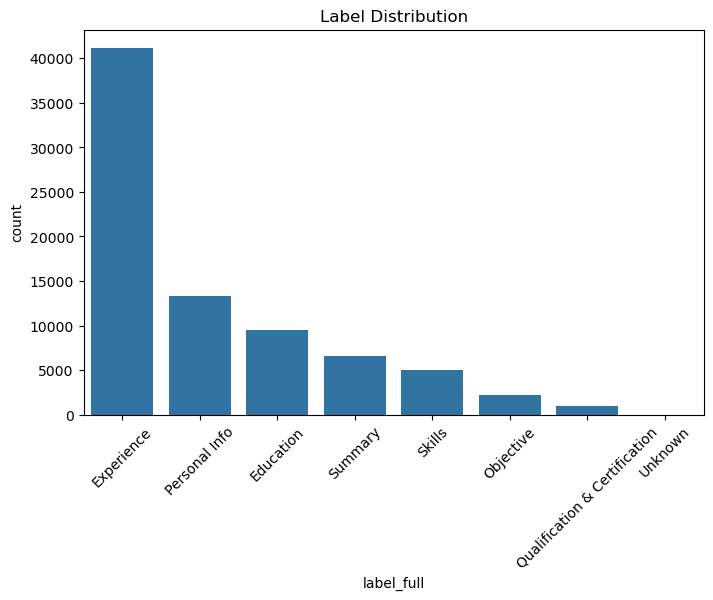

In [3]:
# === 1. Label distribution ===
plt.figure(figsize=(8,5))
sns.countplot(data=initial_dataset, x="label_full", order=initial_dataset["label_full"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Label Distribution")
plt.show()

In [5]:
augmented_dataset = pd.read_csv('../Data/cvs_dataset/final_augmented_dataset.csv')
augmented_dataset.info()
print("duplicates numbers: ", augmented_dataset.duplicated().value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288106 entries, 0 to 288105
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   text                 288106 non-null  object 
 1   token_count          288106 non-null  int64  
 2   char_count           288106 non-null  int64  
 3   avg_word_length      288106 non-null  float64
 4   unique_word_ratio    288106 non-null  float64
 5   stopword_ratio       288106 non-null  float64
 6   punctuation_count    288106 non-null  int64  
 7   comma_count          288106 non-null  int64  
 8   period_count         288106 non-null  int64  
 9   digit_count          288106 non-null  int64  
 10  uppercase_ratio      288106 non-null  float64
 11  bullet_point_flag    288106 non-null  int64  
 12  contains_year        288106 non-null  int64  
 13  special_char_count   288106 non-null  int64  
 14  avg_sentence_length  288106 non-null  float64
 15  long_word_ratio  

In [6]:
augmented_dataset.head()

,text,token_count,char_count,avg_word_length,unique_word_ratio,stopword_ratio,punctuation_count,comma_count,period_count,digit_count,uppercase_ratio,bullet_point_flag,contains_year,special_char_count,avg_sentence_length,long_word_ratio,titlecase_ratio,label,label_full
0,Project under Graduation,4,28,6.25,1.0000,0.2500,0,0,0,0,0.1200,0,0,0,4.0,0.5000,0.7500,Exp,Experience
1,Father’s Name,4,16,3.25,1.0000,0.2500,0,0,0,0,0.3077,0,0,0,4.0,0.0000,0.5000,PI,Personal Info
2,"Omgeo Connect, a complementary offering to Omg...",114,858,6.40,0.6579,0.2544,16,5,3,0,0.0205,0,0,6,28.5,0.5175,0.1053,Exp,Experience
3,Implemented Singleton pattern for property loa...,18,117,5.39,0.9444,0.2222,3,2,1,0,0.0515,0,0,0,18.0,0.4444,0.1667,Exp,Experience
4,· Developed report for Plan Vs Actual Billing ...,33,196,4.85,0.6364,0.2727,2,0,2,0,0.0938,0,0,0,16.5,0.2121,0.2424,Exp,Experience


In [15]:
aug_df_clean = augmented_dataset.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)

# Or, if you want to drop based on all columns (stricter)
# aug_df_clean = aug_df.drop_duplicates().reset_index(drop=True)

print("Before cleaning:", augmented_dataset.shape)
print("After cleaning:", aug_df_clean.shape)
print("\nCleaned class counts:\n", aug_df_clean['label_full'].value_counts().sort_index())

Before cleaning: (288106, 19)
After cleaning: (161021, 19)

Cleaned class counts:
 label_full
Education                        18260
Experience                       34077
Objective                        20219
Personal Info                    22174
Qualification & Certification    14941
Skills                           21646
Summary                          29704
Name: count, dtype: int64


In [10]:
features = [
    "token_count", "char_count", "avg_word_length", "unique_word_ratio",
    "stopword_ratio", "punctuation_count", "comma_count", "period_count",
    "digit_count", "uppercase_ratio", "special_char_count", 
    "avg_sentence_length", "long_word_ratio", "titlecase_ratio"
]

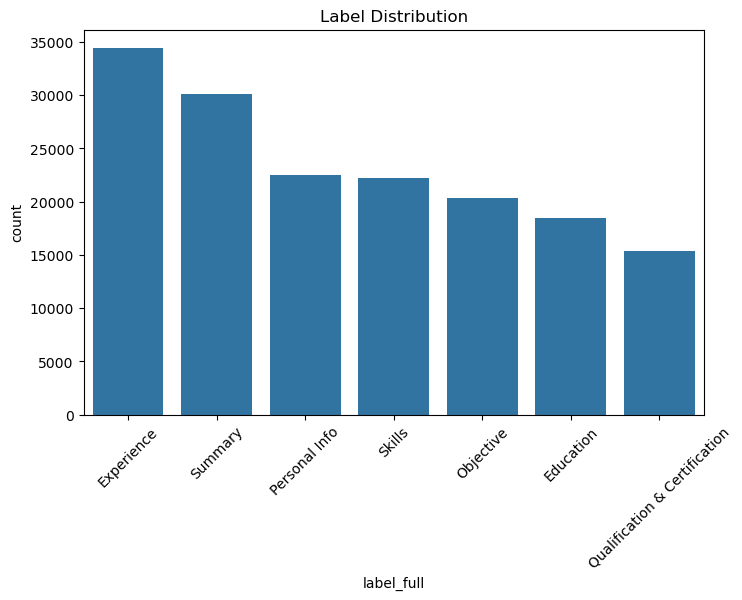

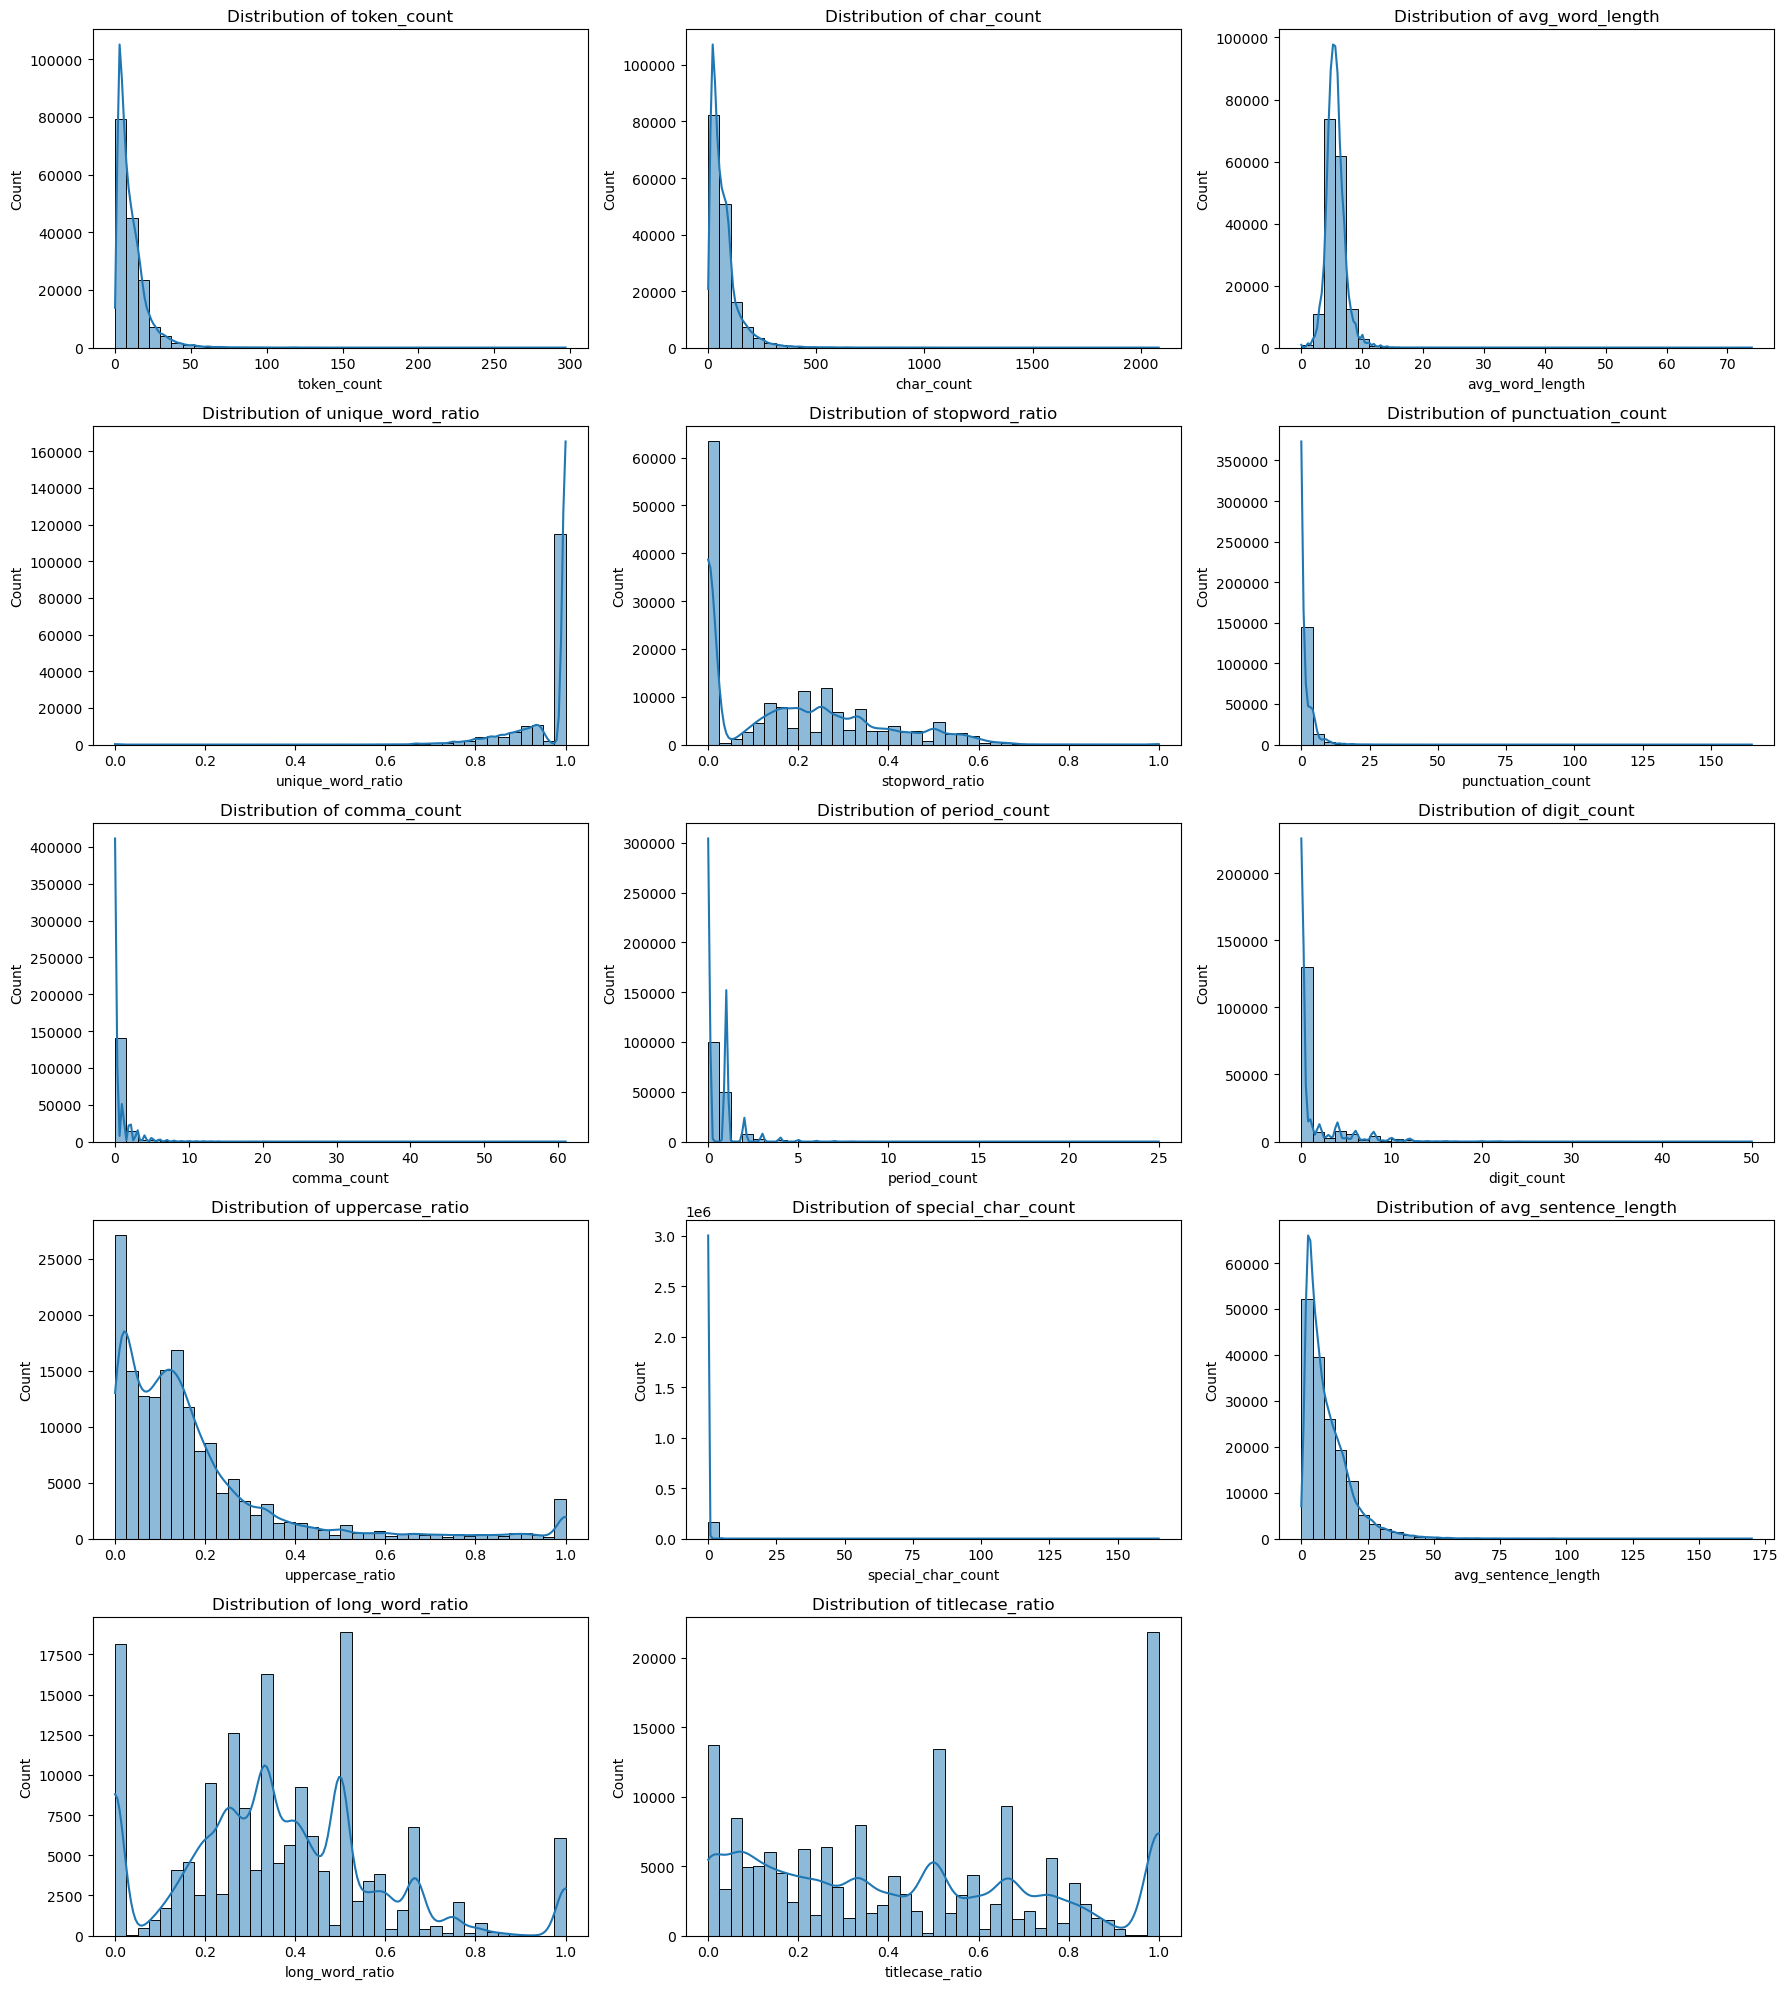

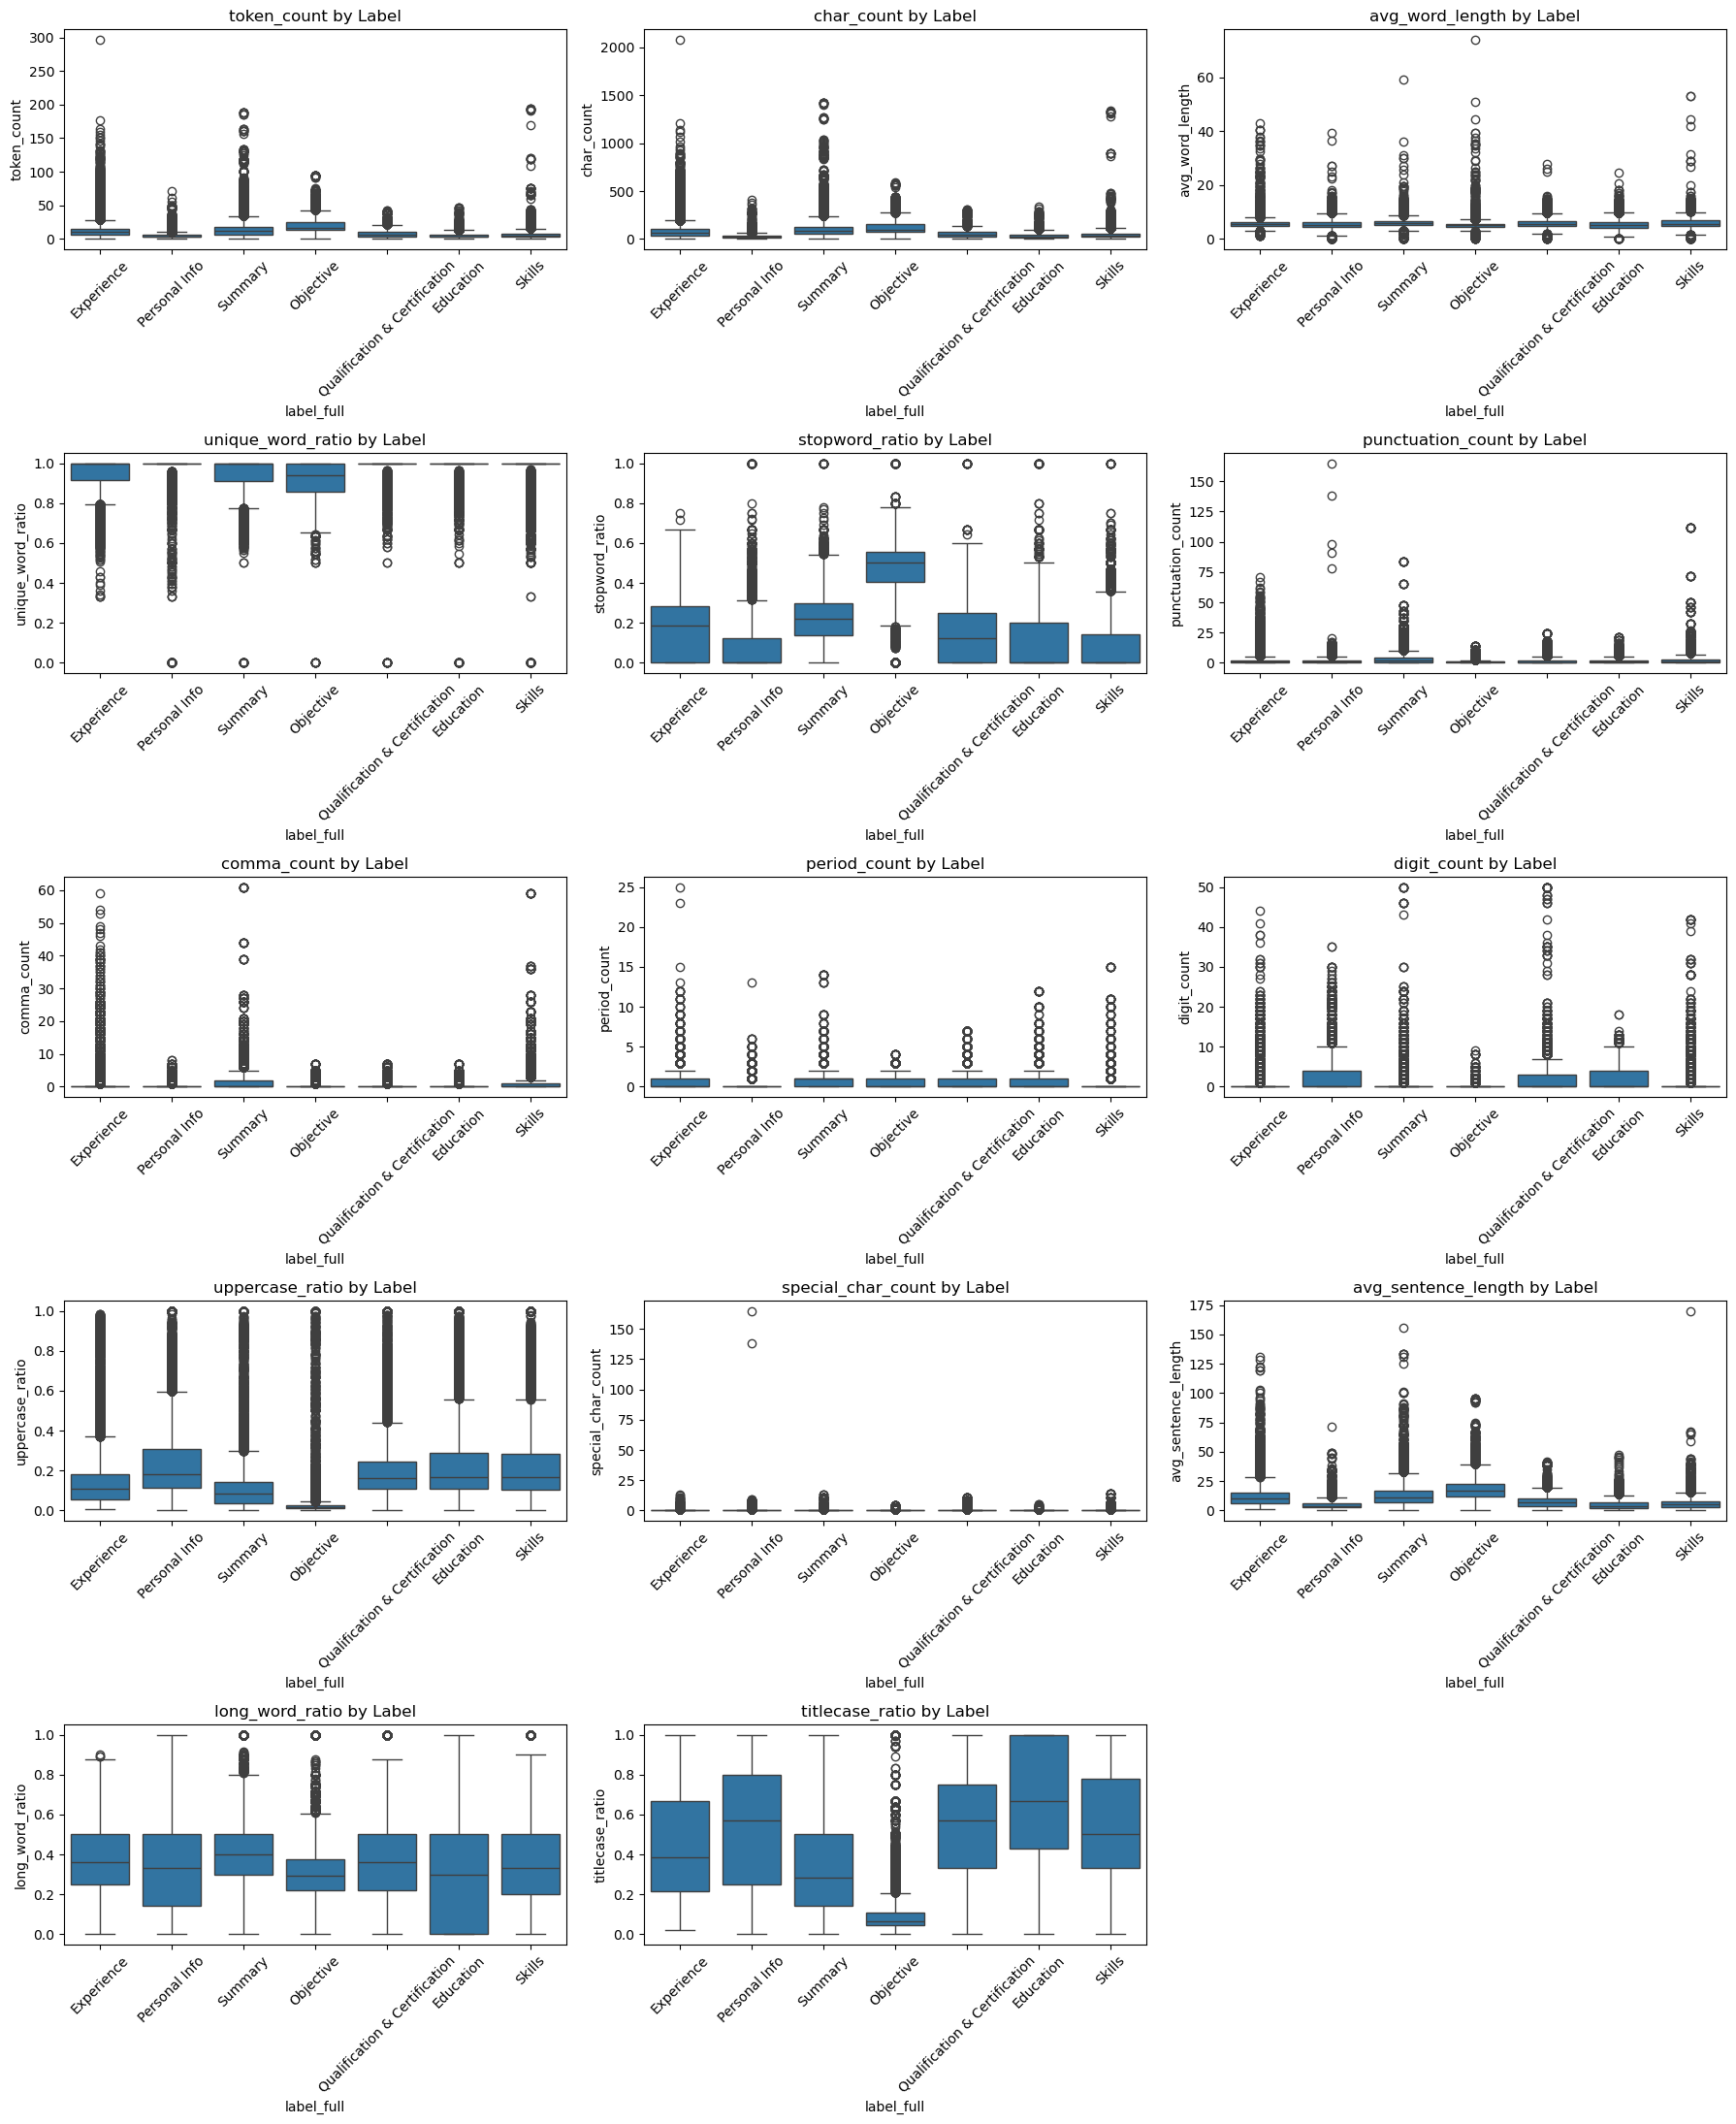

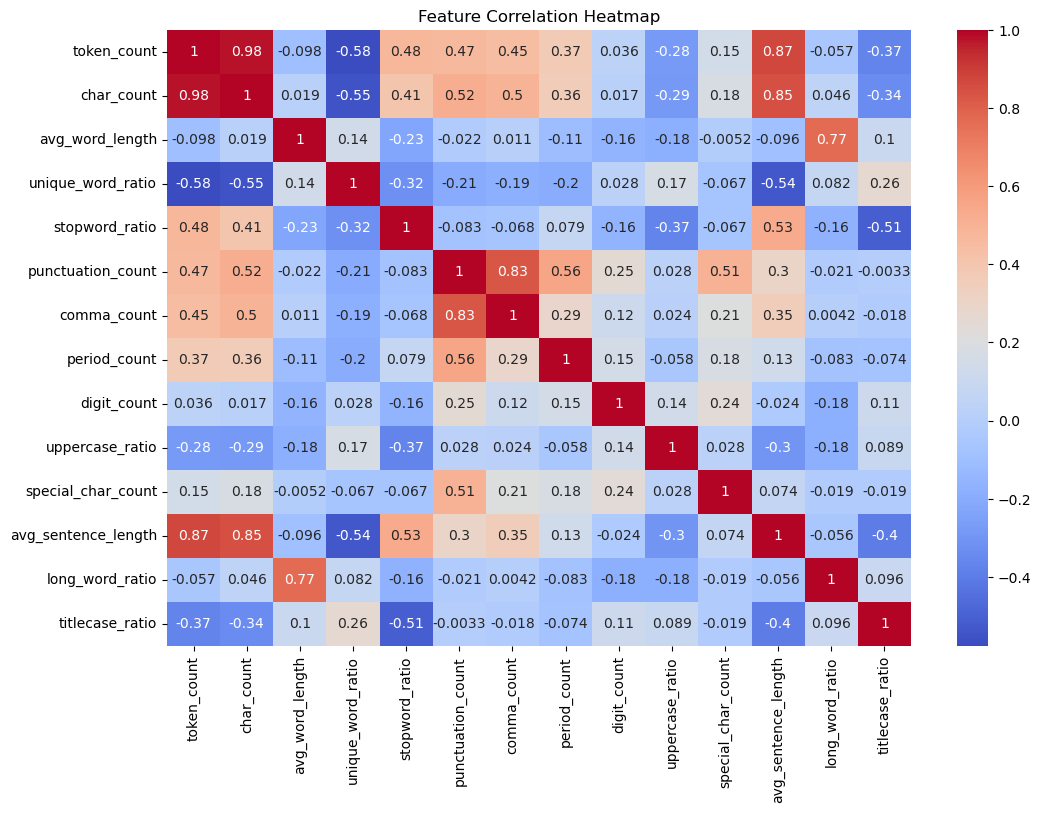

In [12]:
# === 1. Label distribution ===
plt.figure(figsize=(8,5))
sns.countplot(data=aug_df_clean, x="label_full", order=aug_df_clean["label_full"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Label Distribution")
plt.show()

# === 2. Histograms of numeric features (grouped) ===
fig, axes = plt.subplots(5, 3, figsize=(18, 20))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.histplot(aug_df_clean[feat], bins=40, ax=axes[i], kde=True)
    axes[i].set_title(f"Distribution of {feat}")

# Hide any empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# === 3. Boxplots by label (grouped) ===
fig, axes = plt.subplots(5, 3, figsize=(18, 22))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.boxplot(data=aug_df_clean, x="label_full", y=feat, ax=axes[i])
    axes[i].set_title(f"{feat} by Label")
    axes[i].tick_params(axis="x", rotation=45)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# === 4. Correlation heatmap ===
plt.figure(figsize=(12,8))
sns.heatmap(aug_df_clean[features].corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()